In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer
from feature_engine.imputation import RandomSampleImputer
from feature_engine import transformation
from scipy import stats
import pylab

In [5]:
df = pd.read_excel(r"C:\Users\my\OneDrive\Desktop\Ecommerce project\5k+ecommerce_dataset (1).xlsx")


In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Location', 'OrderID', 'ProductID',
       'Category', 'Price', 'Quantity', 'Discount(%)', 'PaymentMethod',
       'PurchaseDate', 'Rating', 'ShipmentTime(days)', 'LateDelivery',
       'CourierPartner', 'LastLogin(days)', 'PurchaseFrequency',
       'CartAbandonmentRate', 'ClicksPerSession', 'Revenue', 'Returned',
       'ReturnReason', 'ChurnRiskScore'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(198)

In [8]:
# 1. TYPE CASTING

# Convert ID columns to string (Nominal)
df['CustomerID'] = df['CustomerID'].astype(str)
df['OrderID'] = df['OrderID'].astype(str)
df['ProductID'] = df['ProductID'].astype(str)


In [9]:
df.dtypes

CustomerID                     object
Age                           float64
Gender                         object
Location                       object
OrderID                        object
ProductID                      object
Category                       object
Price                         float64
Quantity                        int64
Discount(%)                     int64
PaymentMethod                  object
PurchaseDate           datetime64[ns]
Rating                        float64
ShipmentTime(days)            float64
LateDelivery                     bool
CourierPartner                 object
LastLogin(days)                 int64
PurchaseFrequency              object
CartAbandonmentRate           float64
ClicksPerSession                int64
Revenue                       float64
Returned                         bool
ReturnReason                   object
ChurnRiskScore                float64
dtype: object

In [10]:

# Convert categorical columns to category dtype
cat_cols = [
    'Gender','Location','Category','PaymentMethod','LateDelivery',
    'CourierPartner','Returned','ReturnReason'
]

df[cat_cols] = df[cat_cols].astype('category')


In [11]:
# 3. MISSING VALUE IMPUTATION
df.isnull().sum()

CustomerID                0
Age                     257
Gender                    0
Location                  0
OrderID                   0
ProductID                 0
Category                  0
Price                     0
Quantity                  0
Discount(%)               0
PaymentMethod             0
PurchaseDate              0
Rating                  263
ShipmentTime(days)      265
LateDelivery              0
CourierPartner            0
LastLogin(days)           0
PurchaseFrequency         0
CartAbandonmentRate       0
ClicksPerSession          0
Revenue                   0
Returned                  0
ReturnReason           1205
ChurnRiskScore            0
dtype: int64

In [12]:
# Mean/Median for numeric columns
num_cols = ['Age','ShipmentTime(days)','Rating']
median_imputer = SimpleImputer(strategy='median')
df[num_cols] = median_imputer.fit_transform(df[num_cols])

In [13]:
# Mode for categorical columns
mode_imputer = SimpleImputer(strategy='most_frequent')
df[["ReturnReason"]] = mode_imputer.fit_transform(df[["ReturnReason"]])

In [14]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Location               0
OrderID                0
ProductID              0
Category               0
Price                  0
Quantity               0
Discount(%)            0
PaymentMethod          0
PurchaseDate           0
Rating                 0
ShipmentTime(days)     0
LateDelivery           0
CourierPartner         0
LastLogin(days)        0
PurchaseFrequency      0
CartAbandonmentRate    0
ClicksPerSession       0
Revenue                0
Returned               0
ReturnReason           0
ChurnRiskScore         0
dtype: int64

In [15]:
# 3. OUTLIER TREATMENT (Price, Revenue, Rating, Shipment Time)

num_cols = ['Age','Price','Quantity','Discount(%)','ShipmentTime(days)','Rating',
            'ClicksPerSession','Revenue','CartAbandonmentRate',
            'LastLogin(days)','ChurnRiskScore']


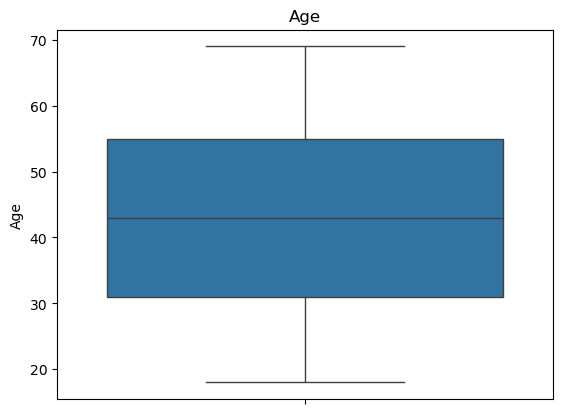

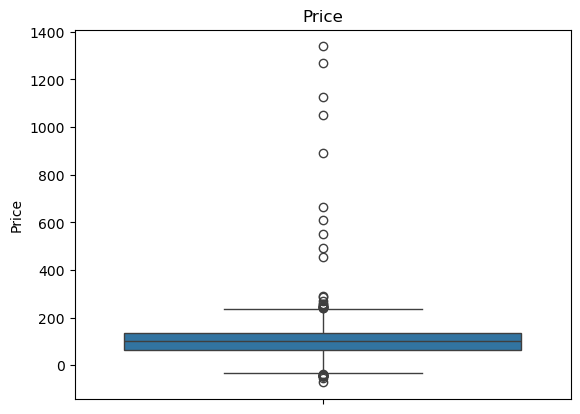

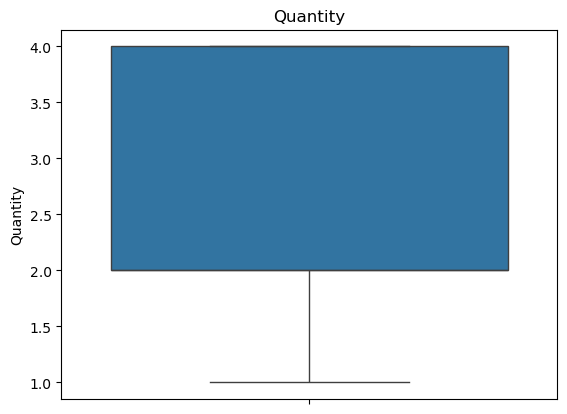

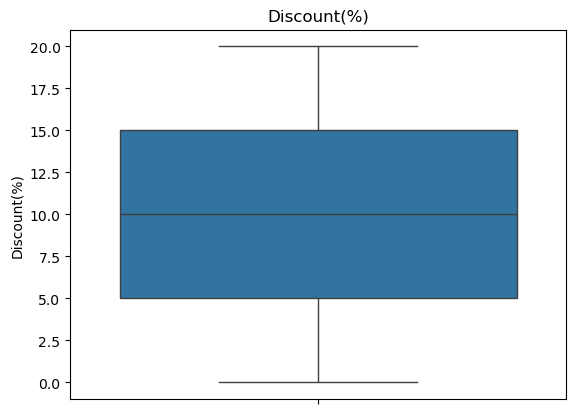

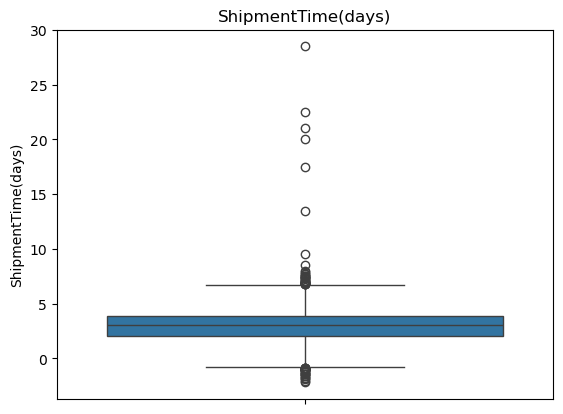

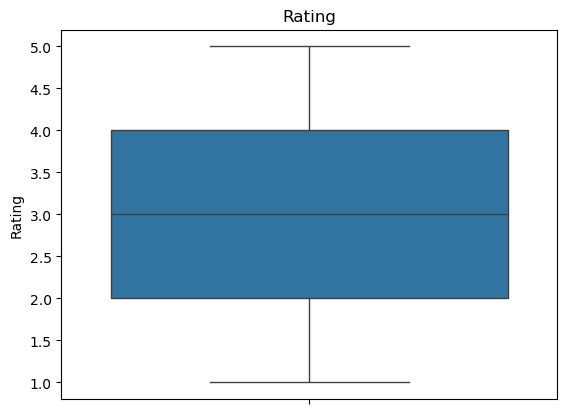

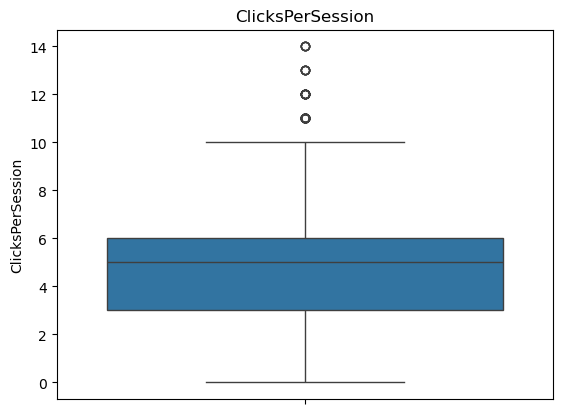

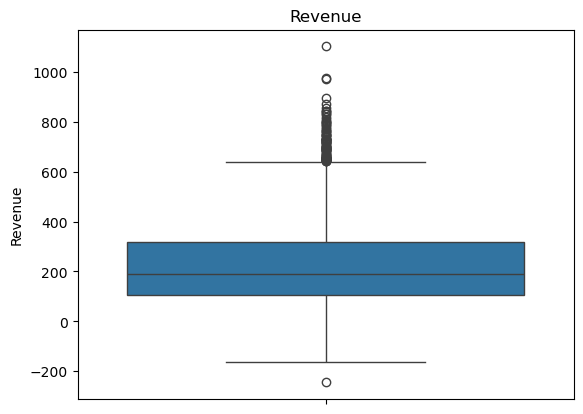

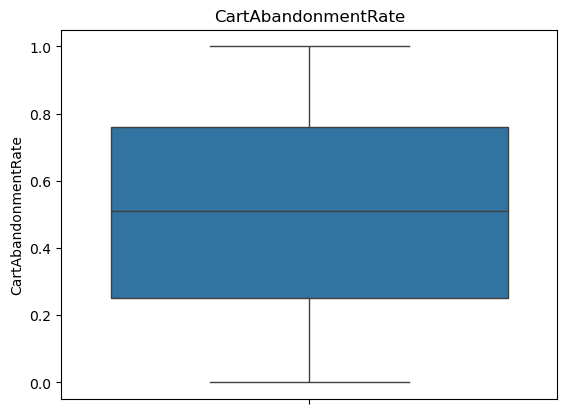

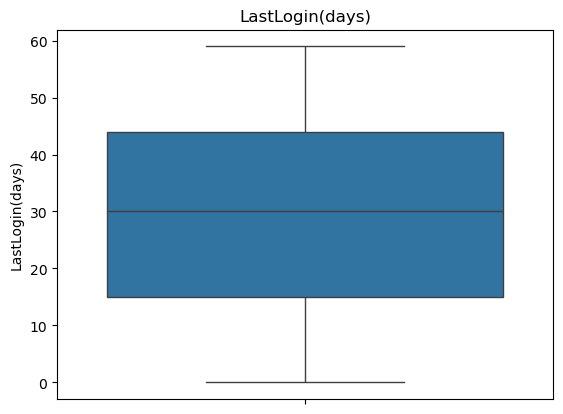

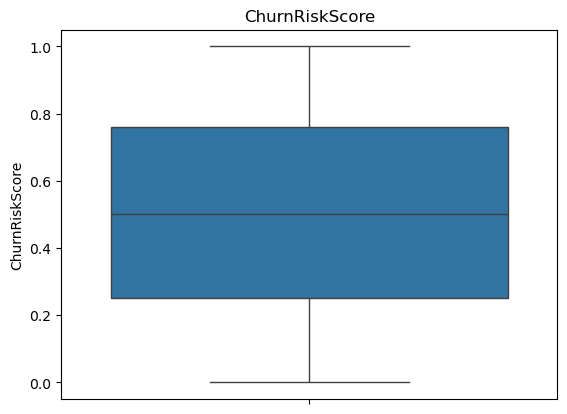

In [16]:
# Boxplots before treatment for all columns
for col in num_cols:
    try:
        sns.boxplot(df[col])
        plt.title(col)
        plt.show()
    except:
        pass

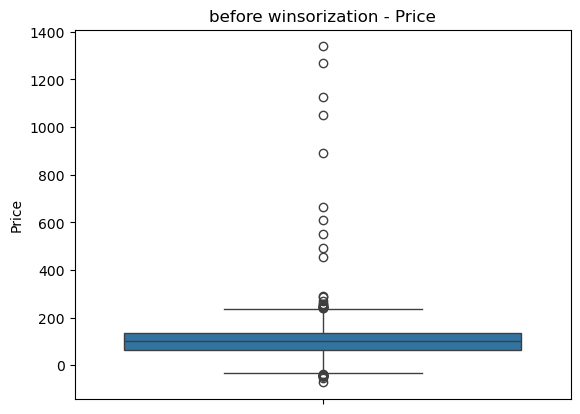

In [20]:
sns.boxplot(df['Price'])
plt.title("before winsorization - Price")
plt.show()

In [21]:
winsor = Winsorizer(capping_method = 'iqr',tail = 'both',fold = 1.5, variables = ['Price'])
df[['Price']] = winsor.fit_transform(df[['Price']])

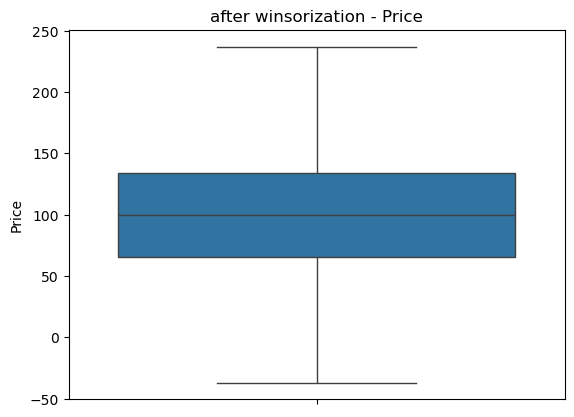

In [22]:
sns.boxplot(df['Price'])
plt.title("after winsorization - Price")
plt.show()

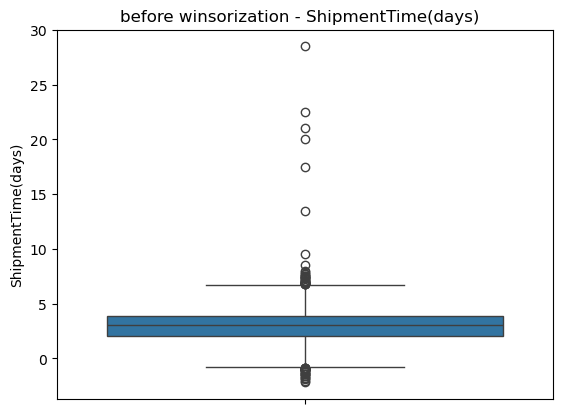

In [29]:
sns.boxplot(df['ShipmentTime(days)'])
plt.title("before winsorization - ShipmentTime(days)  ")
plt.show()

In [30]:
winsor = Winsorizer(capping_method = 'iqr',tail = 'both',fold = 1.5, variables = ['ShipmentTime(days)'])
df[['ShipmentTime(days)']] = winsor.fit_transform(df[['ShipmentTime(days)']])

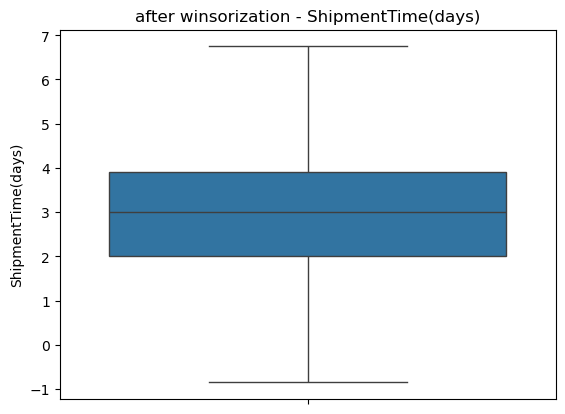

In [31]:
sns.boxplot(df['ShipmentTime(days)'])
plt.title("after winsorization - ShipmentTime(days)")
plt.show()

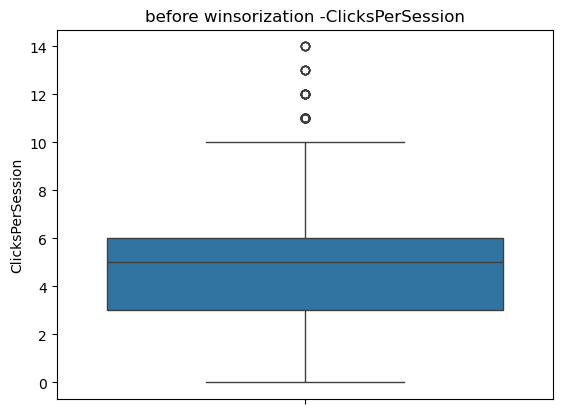

In [35]:
sns.boxplot(df['ClicksPerSession'])
plt.title("before winsorization -ClicksPerSession")
plt.show()

In [36]:
winsor = Winsorizer(capping_method = 'iqr',tail = 'both',fold = 1.5, variables = ['ClicksPerSession'])
df[['ClicksPerSession']] = winsor.fit_transform(df[['ClicksPerSession']])

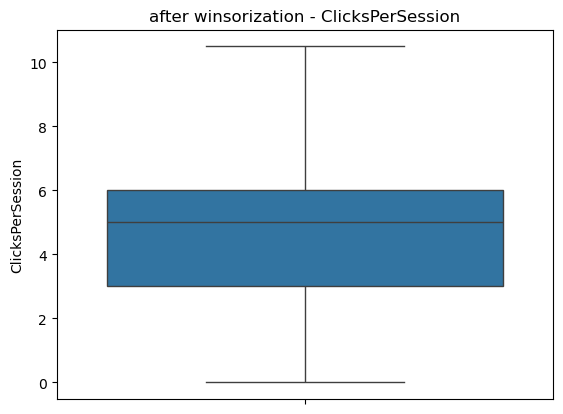

In [37]:
sns.boxplot(df['ClicksPerSession'])
plt.title("after winsorization - ClicksPerSession")
plt.show()

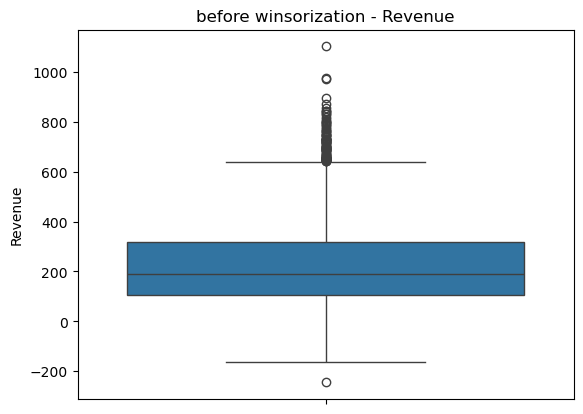

In [38]:
sns.boxplot(df['Revenue'])
plt.title("before winsorization - Revenue")
plt.show()

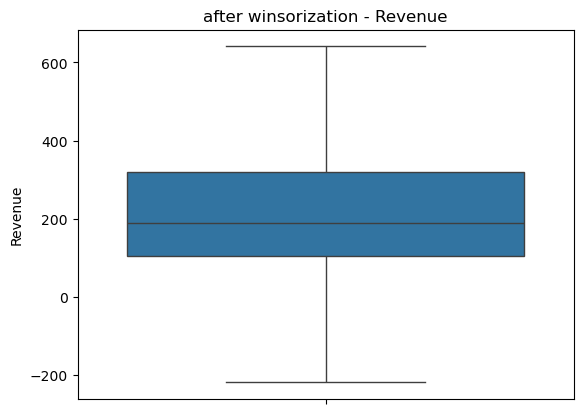

In [40]:
sns.boxplot(df['Revenue'])
plt.title("after winsorization - Revenue")
plt.show()